In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

Configuration des chemins

In [10]:
# Paths configuration
PROCESSED_PATH = '../dattest/processedtest/'
MODELS_PATH = '../models/'

# Create models folder if it does not exist
os.makedirs(MODELS_PATH, exist_ok=True)

print("Processed path :", PROCESSED_PATH)
print("Models path    :", MODELS_PATH)

Processed path : ../dattest/processedtest/
Models path    : ../models/


Chargement des données


In [11]:
# Load image patches and building masks
X = np.load(os.path.join(PROCESSED_PATH, 'X_all.npy'))
Y = np.load(os.path.join(PROCESSED_PATH, 'Y_buildings_all.npy'))

print("Données chargées avec succès.")
print("Shape X :", X.shape)
print("Shape Y :", Y.shape)

Données chargées avec succès.
Shape X : (157, 256, 256, 3)
Shape Y : (157, 256, 256, 1)


Vérification rapide des données

In [12]:
print("===== VÉRIFICATION DES DONNÉES =====")
print("Type X :", X.dtype)
print("Type Y :", Y.dtype)

print("Min X :", X.min())
print("Max X :", X.max())

print("Min Y :", Y.min())
print("Max Y :", Y.max())

===== VÉRIFICATION DES DONNÉES =====
Type X : float32
Type Y : uint8
Min X : 0.0
Max X : 1.0
Min Y : 0
Max Y : 1


Split train / validation / test

In [13]:
# First split: train and temporary set
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Second split: validation and test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("===== SHAPES APRÈS SPLIT =====")
print("X_train :", X_train.shape)
print("Y_train :", Y_train.shape)

print("X_val   :", X_val.shape)
print("Y_val   :", Y_val.shape)

print("X_test  :", X_test.shape)
print("Y_test  :", Y_test.shape)

===== SHAPES APRÈS SPLIT =====
X_train : (109, 256, 256, 3)
Y_train : (109, 256, 256, 1)
X_val   : (24, 256, 256, 3)
Y_val   : (24, 256, 256, 1)
X_test  : (24, 256, 256, 3)
Y_test  : (24, 256, 256, 1)


Dice coefficient et Dice loss

In [14]:
def dice_coef(y_true, y_pred):
    """
    Dice coefficient:
    measures the overlap between ground truth and prediction.
    Higher is better.
    """
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + 1.) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.
    )


def dice_loss(y_true, y_pred):
    """
    Dice loss = 1 - Dice coefficient
    Lower is better.
    """
    return 1.0 - dice_coef(y_true, y_pred)

Métrique IoU

IoU est une autre métrique utile pour mesurer le recouvrement entre masque réel et masque prédit.

In [15]:
def iou_metric(y_true, y_pred):
    """
    Intersection over Union metric.
    """
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + 1.) / (union + 1.)

Construction du modèle U-Net

C’est un U-Net classique :

encodeur pour extraire les caractéristiques
bottleneck
décodeur pour reconstruire le masque
skip connections pour conserver les détails spatiaux

In [16]:
def unet_model(input_size=(256, 256, 3)):
    inputs = Input(input_size)

    # ===== Encoder =====
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = layers.Dropout(0.1)(c1)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = layers.Dropout(0.1)(c2)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = layers.Dropout(0.2)(c3)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # ===== Bottleneck =====
    c4 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = layers.Dropout(0.3)(c4)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)

    # ===== Decoder =====
    u5 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u5)
    c5 = layers.Dropout(0.2)(c5)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    u6 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = layers.Dropout(0.1)(c6)
    c6 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = layers.Dropout(0.1)(c7)
    c7 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    # ===== Output =====
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

Compilation du modèle

On compile le modèle avec :

adam comme optimiseur
dice_loss comme loss
dice_coef et iou_metric comme métriques

In [17]:
model = unet_model()

model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[dice_coef, iou_metric]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │     32,832 │ conv2d_7[0][0]  

 Total params: 482,033 (1.84 MB)

 Trainable params: 482,033 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

Callbacks

EarlyStopping pour arrêter si la validation ne s’améliore plus
ModelCheckpoint pour sauvegarder le meilleur modèle

In [18]:
# Best model path
best_model_path = os.path.join(MODELS_PATH, 'unet_buildings_best.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configurés.")
print("Best model path :", best_model_path)

Callbacks configurés.
Best model path : ../models/unet_buildings_best.keras


Entraînement

In [19]:
print("Début de l'entraînement du modèle bâtiments...")

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=8,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

print("Entraînement terminé.")

Début de l'entraînement du modèle bâtiments...
Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - dice_coef: 0.0757 - iou_metric: 0.0365 - loss: 0.9241
Epoch 1: val_loss improved from None to 0.89835, saving model to ../models/unet_buildings_best.keras

Epoch 1: finished saving model to ../models/unet_buildings_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 604ms/step - dice_coef: 0.0833 - iou_metric: 0.0408 - loss: 0.9150 - val_dice_coef: 0.1017 - val_iou_metric: 0.1697 - val_loss: 0.8983
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - dice_coef: 0.1090 - iou_metric: 0.0967 - loss: 0.8910
Epoch 2: val_loss improved from 0.89835 to 0.82756, saving model to ../models/unet_buildings_best.keras

Epoch 2: finished saving model to ../models/unet_buildings_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 537ms/step - dice_coef: 0.1264 - iou_metric: 0.1030 - loss: 0.8732 - val_dice_coef: 0.1724 - val_iou_metric: 0.1031 - val_loss: 0.8276
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - dice_

Courbes d’apprentissage

affiche:

la loss
le Dice coefficient
le IoU

pour voir si le modèle apprend correctement.

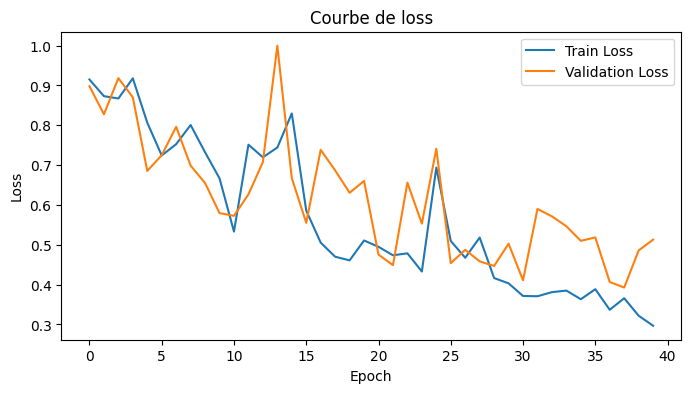

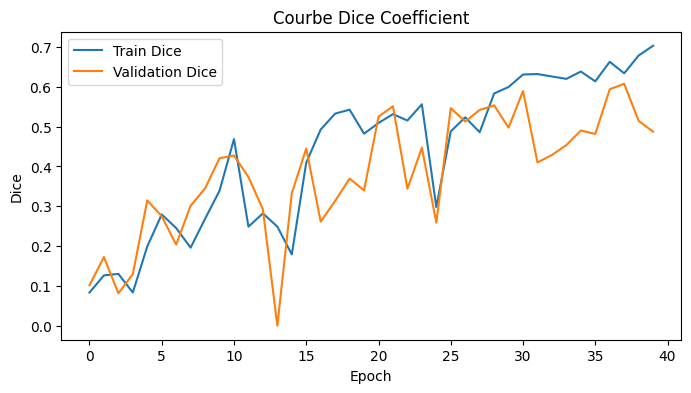

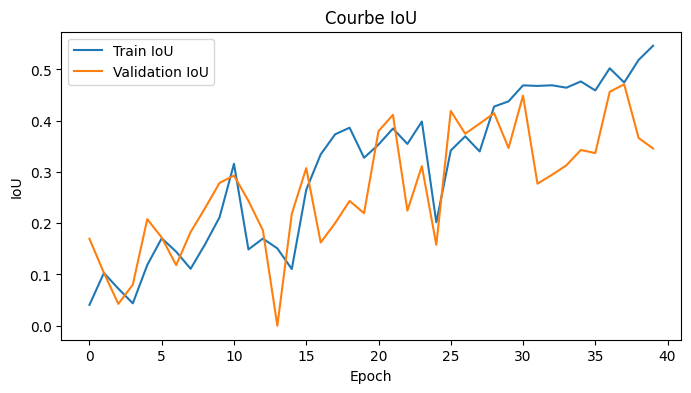

In [20]:
# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Courbe de loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot Dice coefficient
plt.figure(figsize=(8, 4))
plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')
plt.title("Courbe Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.show()

# Plot IoU
plt.figure(figsize=(8, 4))
plt.plot(history.history['iou_metric'], label='Train IoU')
plt.plot(history.history['val_iou_metric'], label='Validation IoU')
plt.title("Courbe IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.show()

Évaluation sur le jeu de test

In [21]:
print("Évaluation sur le jeu de test...")

test_results = model.evaluate(X_test, Y_test, verbose=1)

print("\n===== RÉSULTATS TEST =====")
print("Test Loss       :", test_results[0])
print("Test Dice       :", test_results[1])
print("Test IoU        :", test_results[2])

Évaluation sur le jeu de test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - dice_coef: 0.6684 - iou_metric: 0.5021 - loss: 0.3316

===== RÉSULTATS TEST =====
Test Loss       : 0.3316059112548828
Test Dice       : 0.6683940887451172
Test IoU        : 0.5020906329154968


Chargement du meilleur modèle

On recharge le meilleur modèle sauvegardé par ModelCheckpoint.

In [22]:
best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        'dice_loss': dice_loss,
        'dice_coef': dice_coef,
        'iou_metric': iou_metric
    }
)

print("Meilleur modèle chargé avec succès.")

Meilleur modèle chargé avec succès.


Prédiction sur quelques exemples du test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


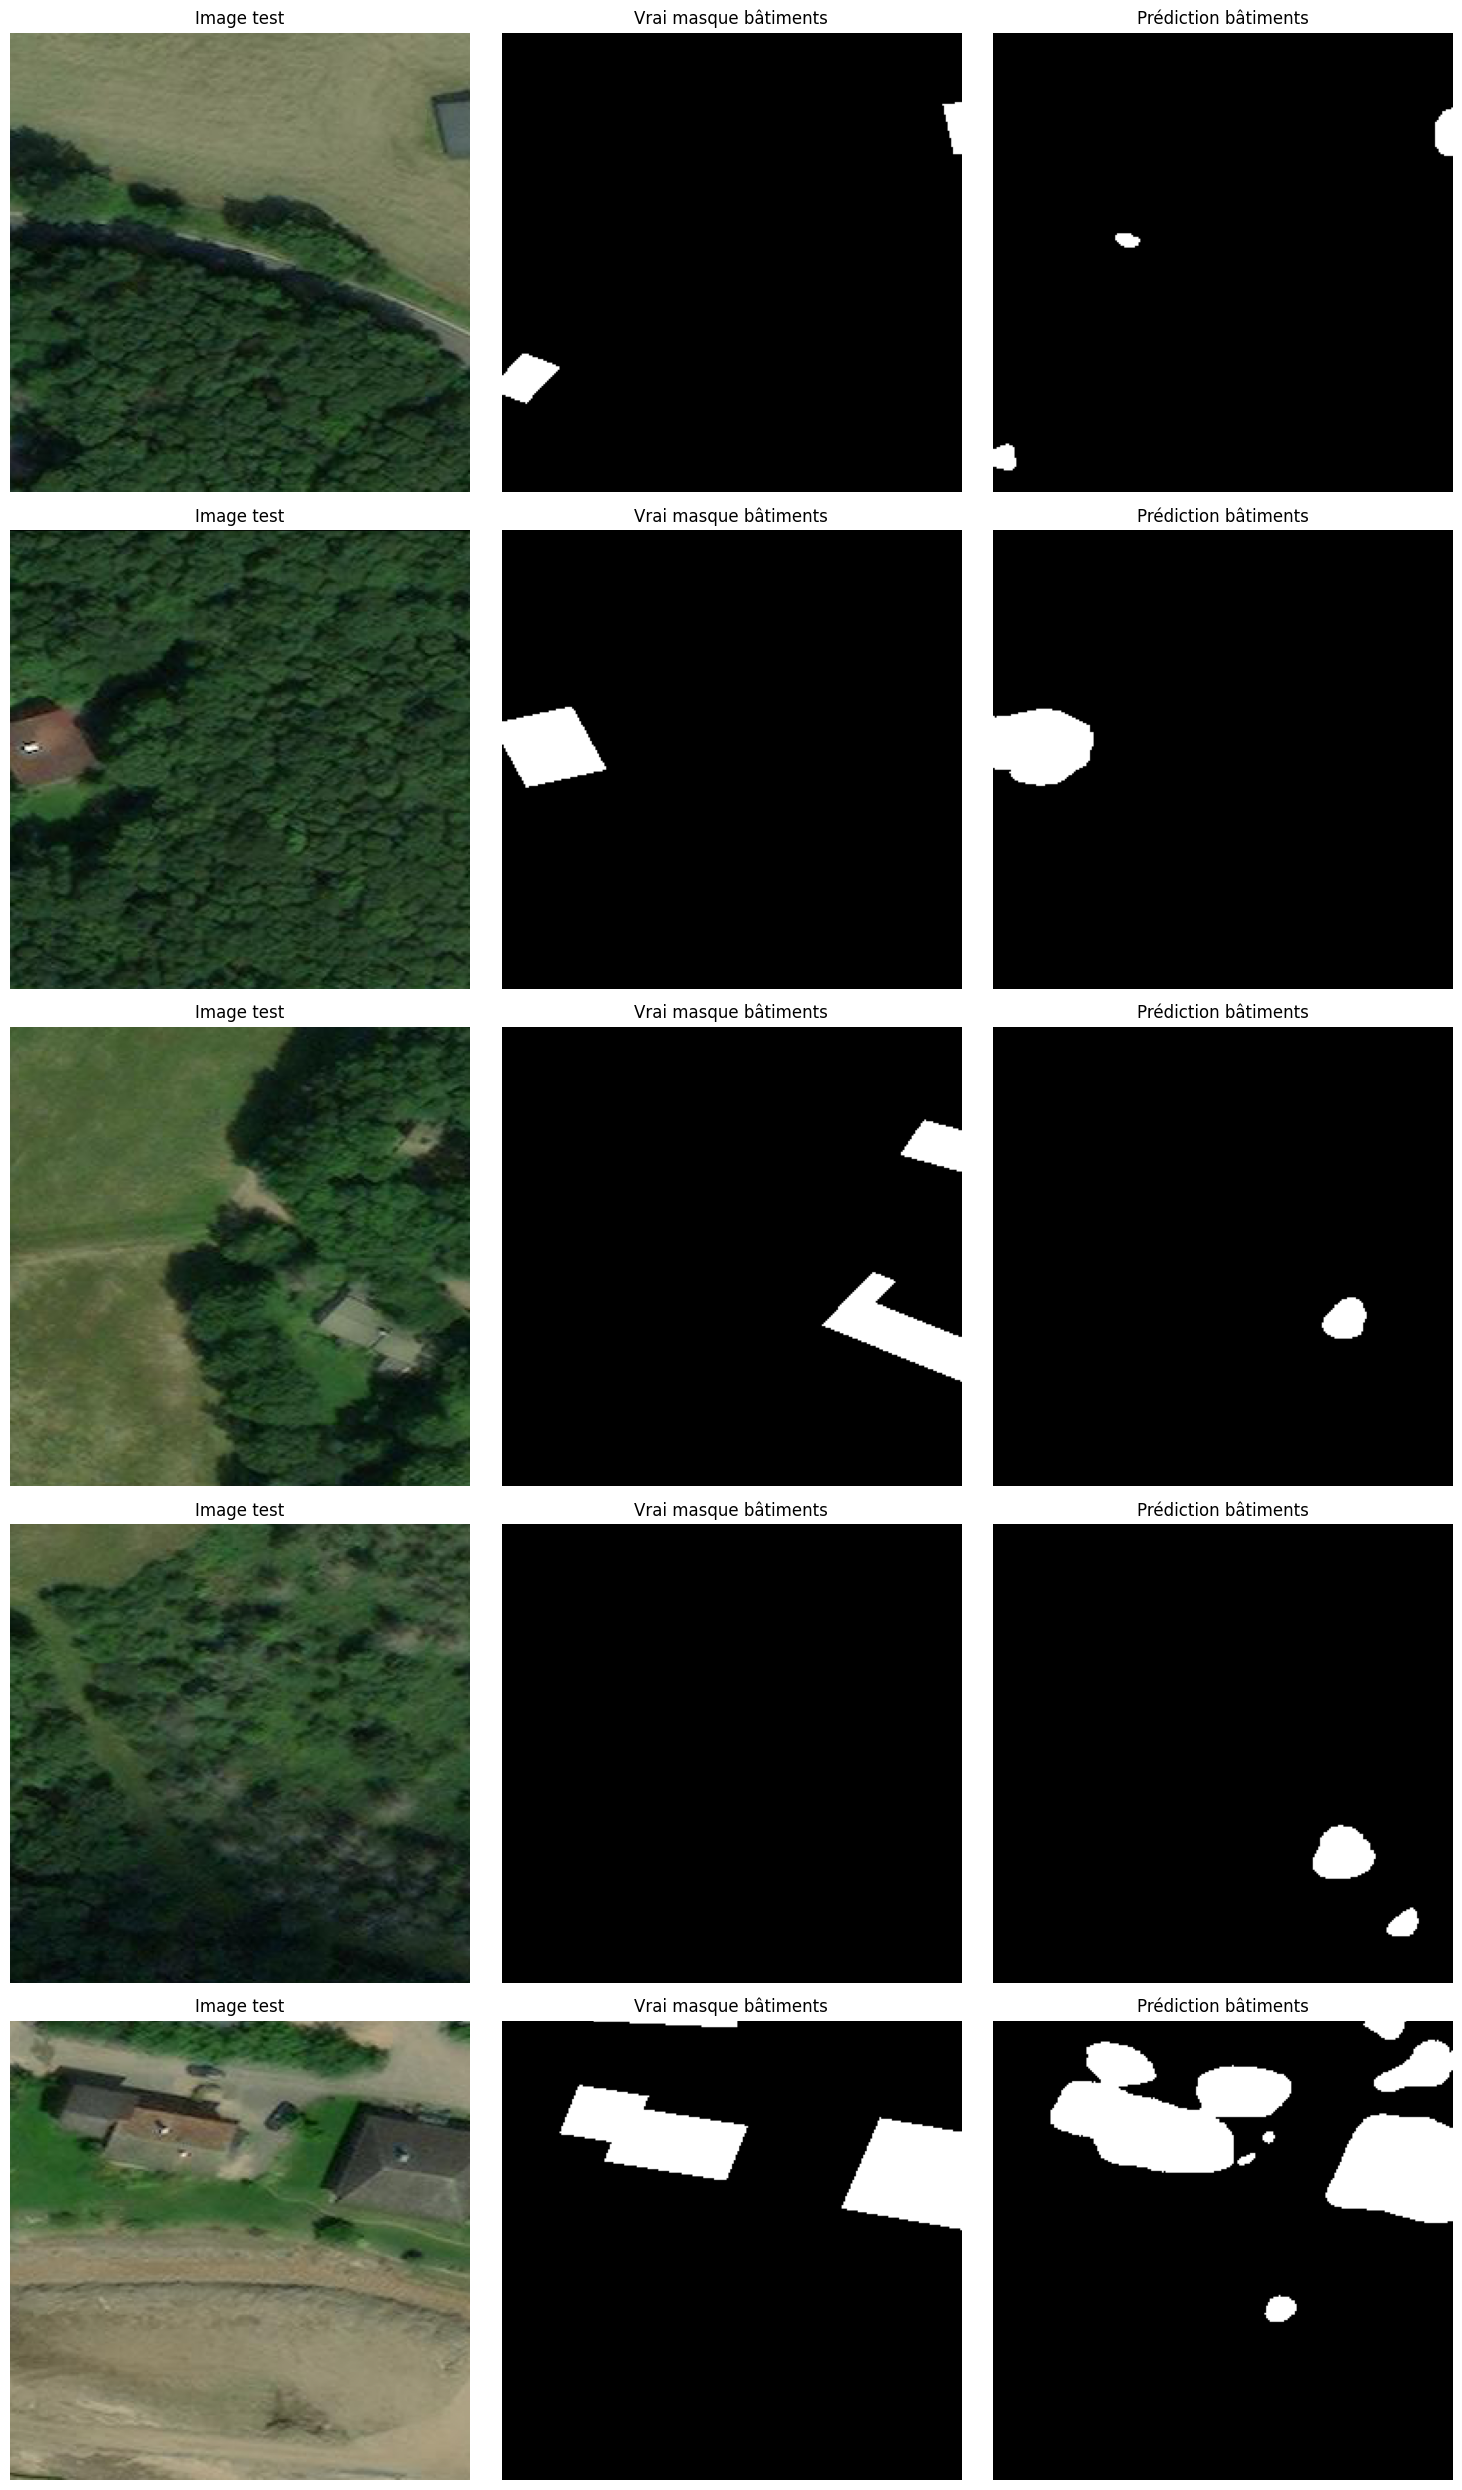

In [23]:
num_examples = min(5, len(X_test))
indices = np.random.choice(len(X_test), size=num_examples, replace=False)

preds = best_model.predict(X_test[indices])
preds_bin = (preds > 0.5).astype(np.uint8)

plt.figure(figsize=(15, 5 * num_examples))

for k, idx in enumerate(range(num_examples)):
    plt.subplot(num_examples, 3, 3*k + 1)
    plt.imshow(X_test[indices][idx])
    plt.title("Image test")
    plt.axis('off')

    plt.subplot(num_examples, 3, 3*k + 2)
    plt.imshow(Y_test[indices][idx].squeeze(), cmap='gray')
    plt.title("Vrai masque bâtiments")
    plt.axis('off')

    plt.subplot(num_examples, 3, 3*k + 3)
    plt.imshow(preds_bin[idx].squeeze(), cmap='gray')
    plt.title("Prédiction bâtiments")
    plt.axis('off')

plt.tight_layout()
plt.show()

Probabilités brutes

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step


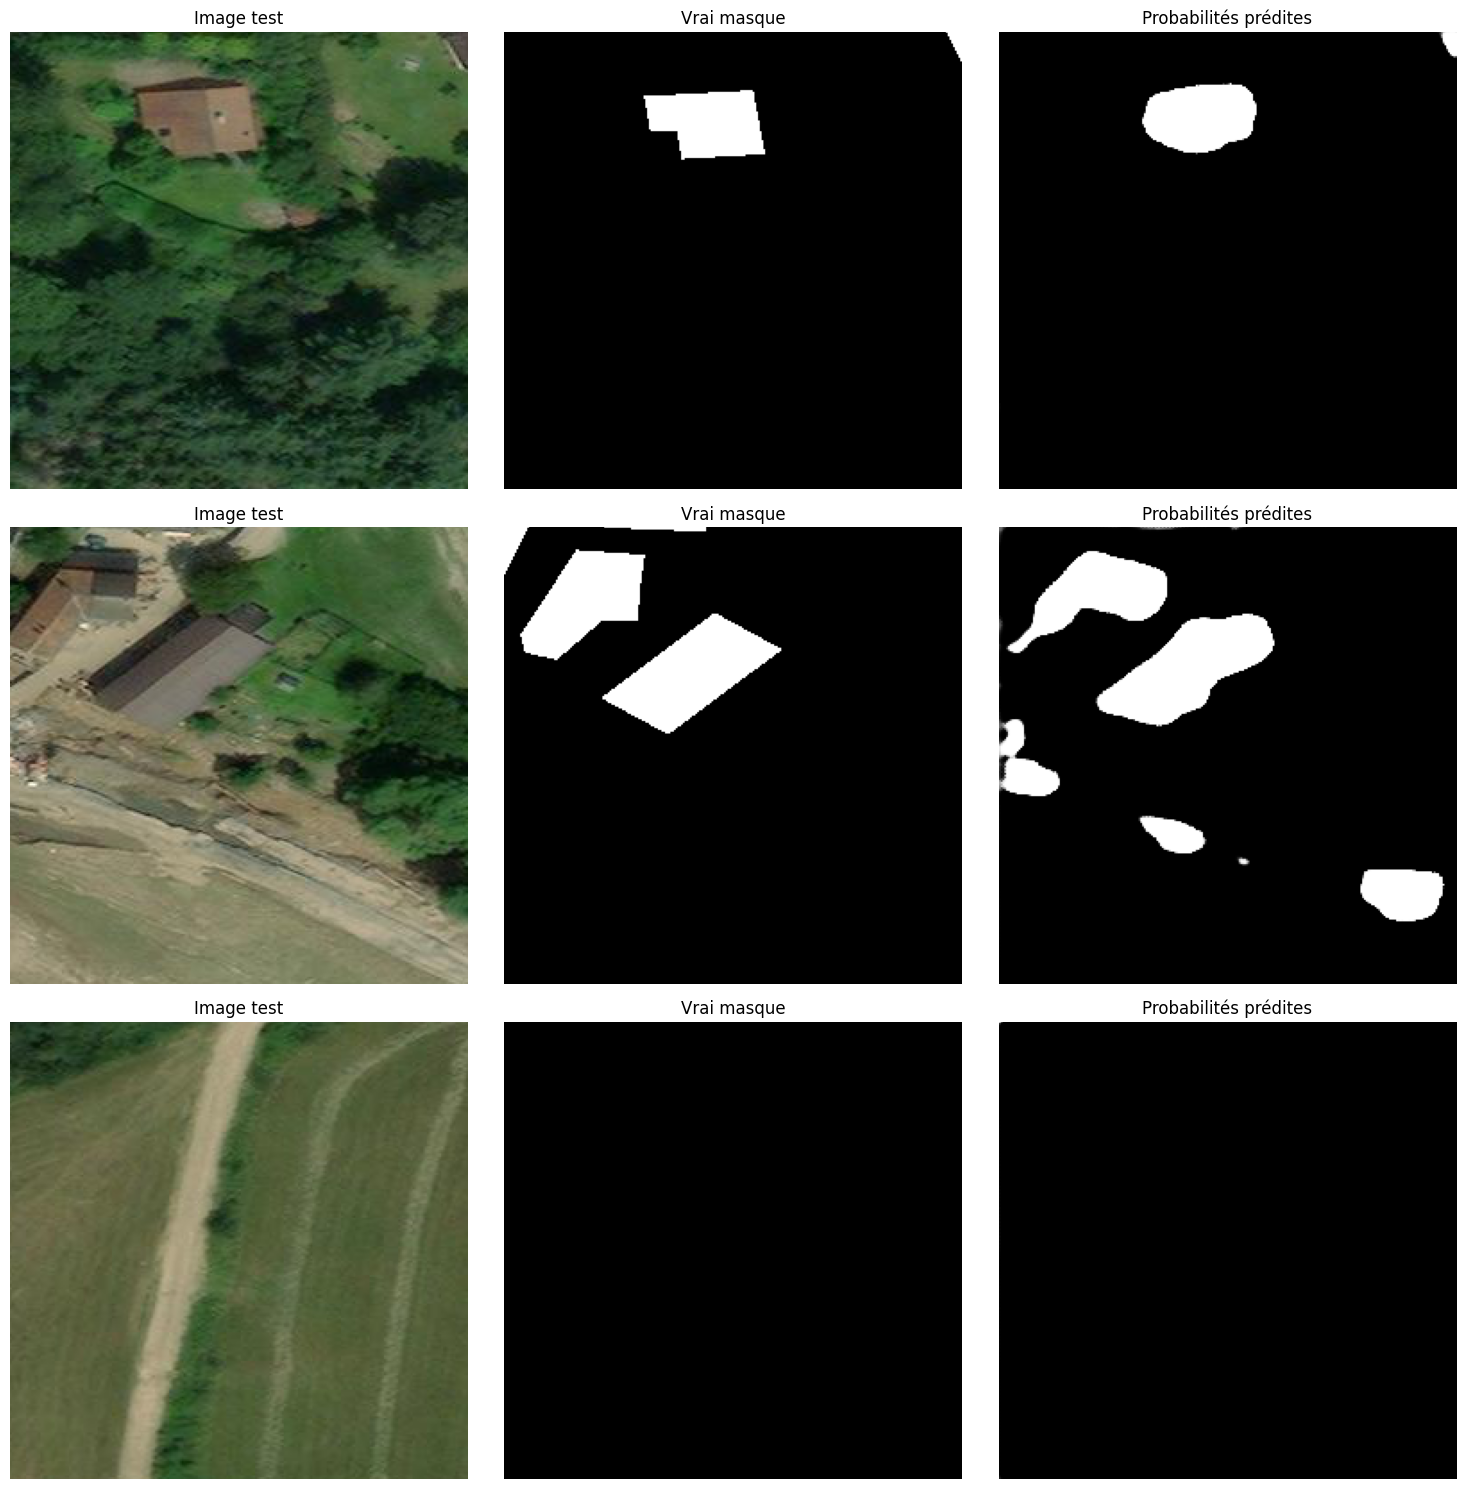

In [24]:
num_examples = min(3, len(X_test))
indices = np.random.choice(len(X_test), size=num_examples, replace=False)

preds = best_model.predict(X_test[indices])

plt.figure(figsize=(15, 5 * num_examples))

for k, idx in enumerate(range(num_examples)):
    plt.subplot(num_examples, 3, 3*k + 1)
    plt.imshow(X_test[indices][idx])
    plt.title("Image test")
    plt.axis('off')

    plt.subplot(num_examples, 3, 3*k + 2)
    plt.imshow(Y_test[indices][idx].squeeze(), cmap='gray')
    plt.title("Vrai masque")
    plt.axis('off')

    plt.subplot(num_examples, 3, 3*k + 3)
    plt.imshow(preds[idx].squeeze(), cmap='gray')
    plt.title("Probabilités prédites")
    plt.axis('off')

plt.tight_layout()
plt.show()

Sauvegarde finale

In [25]:
final_model_path = os.path.join(MODELS_PATH, 'unet_buildings_final.keras')

model.save(final_model_path)

print("Modèle final sauvegardé avec succès.")
print("Chemin :", final_model_path)

Modèle final sauvegardé avec succès.
Chemin : ../models/unet_buildings_final.keras


Résumé final

In [26]:
print("===== RÉSUMÉ FINAL =====")
print("Dataset total          :", X.shape)
print("Train set              :", X_train.shape)
print("Validation set         :", X_val.shape)
print("Test set               :", X_test.shape)

print("\nModèles sauvegardés :")
print("- Best model  :", best_model_path)
print("- Final model :", final_model_path)

===== RÉSUMÉ FINAL =====
Dataset total          : (157, 256, 256, 3)
Train set              : (109, 256, 256, 3)
Validation set         : (24, 256, 256, 3)
Test set               : (24, 256, 256, 3)

Modèles sauvegardés :
- Best model  : ../models/unet_buildings_best.keras
- Final model : ../models/unet_buildings_final.keras
